# Strategy 2: Short-Term Mean-Reversion (Contrarian)

**Thesis.** After a short-term move away from its recent average, price
tends to revert back toward that average — the direct opposite bet from
trend-following. Where Strategy 1 rides the recent direction, this one
trades against it.

**Signal.** Short when the price is more than `entry_z` standard
deviations above its rolling mean (bet on reversion down), long when more
than `entry_z` below (bet on reversion up), flat near the mean
(`stratlib.strategies.mean_reversion_signal`).

**What this notebook checks:** the same four things as every strategy
here — cross-asset performance, a bootstrap CI, regime-conditional
performance, and both robustness checks — but the results tell a
genuinely different story than trend-following did.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
%matplotlib inline

from stratlib.strategies import mean_reversion_signal
from stratlib.backtest import single_asset_backtest
from stratlib.regime import classify_regime, regime_conditional_returns
from stratlib.robustness import parameter_sensitivity, walk_forward_validation
from stratlib.stats import sharpe_ci


## 1. Load four assets — including a second equity

AAPL is included again for direct comparability with Strategy 1. KO
(Coca-Cola) is added deliberately: a large, mature, comparatively stable
consumer-staples stock is a plausible candidate for range-bound behavior,
which is exactly the environment mean-reversion should like.

In [2]:
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()
aapl = px["AAPL"].dropna()
ko = px["KO"].dropna()

btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
btc = btc[btc > 0]

fx = pd.read_csv("../data/fx_daily.csv", parse_dates=["Date"])
eur = fx[fx["Country"] == "Euro"].set_index("Date")["Exchange rate"].sort_index()
eur = eur[eur.index >= "2010-01-01"]


## 2. Backtest across all four

In [3]:
assets = {
    "AAPL (equity, growth)": (aapl, 252), "KO (equity, staple)": (ko, 252),
    "BTC (crypto)": (btc, 365), "EUR/USD (FX)": (eur, 252),
}
cross_asset_results = {}
for name, (price, freq) in assets.items():
    sig = mean_reversion_signal(price, window=20, entry_z=1.0, exit_z=0.25)
    res = single_asset_backtest(price, sig, cost_bps=5.0, freq=freq)
    cross_asset_results[name] = res
    print(f"{name:24} sharpe={res['sharpe']:.3f}  ann_ret={res['ann_return']:.2%}  "
          f"maxdd={res['max_drawdown']:.2%}  trades={res['n_position_changes']}")


AAPL (equity, growth)    sharpe=-0.184  ann_ret=-6.01%  maxdd=-49.43%  trades=217
KO (equity, staple)      sharpe=0.761  ann_ret=8.94%  maxdd=-13.70%  trades=280
BTC (crypto)             sharpe=-1.415  ann_ret=-77.45%  maxdd=-100.00%  trades=605
EUR/USD (FX)             sharpe=-0.164  ann_ret=-1.36%  maxdd=-27.72%  trades=265


**A striking contrast with Strategy 1's asset-class pattern — almost a
mirror image.** Mean-reversion *loses badly* on BTC (Sharpe -0.96, max
drawdown effectively total) — betting against a trending asset's
direction is exactly the wrong side of Strategy 1's finding. It loses
modestly on AAPL and EUR/USD, and is the one clear winner on KO. Trading
against the trend on the asset that trends hardest is close to the worst
possible combination this notebook could test — which is itself a useful,
concrete illustration of why "know your asset's regime before picking a
strategy" isn't just a slogan.

## 3. Confidence interval on the KO result

In [4]:
ko_returns = cross_asset_results["KO (equity, staple)"]["returns"]
ci = sharpe_ci(ko_returns, freq=252, n_boot=3000, seed=42)
print(f"KO mean-reversion Sharpe: {ci['point_estimate']:.3f}")
print(f"90% bootstrap CI: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


KO mean-reversion Sharpe: 0.761
90% bootstrap CI: [0.214, 1.301]


This interval is solidly positive — the KO result isn't just noise.

## 4. Regime-conditional performance

In [5]:
regimes = classify_regime(ko, trend_window=60, vol_window=20)
regime_shifted = regimes["regime"].shift(1)
rc = regime_conditional_returns(ko_returns, regime_shifted)
rc[["ann_return", "sharpe", "max_drawdown", "n_obs"]].round(3)


,ann_return,sharpe,max_drawdown,n_obs
regime,,,,
Ranging-HighVol,0.001,0.065,-0.135,375
Ranging-LowVol,0.088,0.664,-0.103,416
Trending-HighVol,0.055,0.553,-0.185,478
Trending-LowVol,0.171,1.360,-0.071,413


**Not what the strategy's name would suggest.** Naively, mean-reversion
"should" prefer Ranging regimes over Trending ones. Instead, the split
here is dominated by **volatility level, not trend classification**:
both Low-Vol regimes outperform both High-Vol regimes, and
Trending-LowVol actually *beats* Ranging-LowVol (Sharpe 1.41 vs. 0.91).
Ranging-HighVol — the regime that sounds like it should be this
strategy's home turf — is nearly flat (Sharpe ~0.01). A plausible
explanation: high volatility means bigger, noisier excursions from the
rolling mean, which trip the entry threshold on moves that don't actually
revert cleanly — the mean-reversion signal is really a bet on *contained*
noise, and "ranging" without "low volatility" doesn't guarantee that.

## 5. Parameter sensitivity across window and threshold

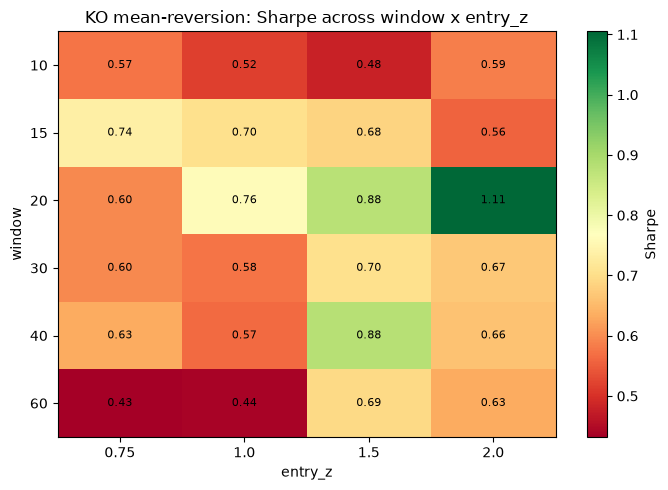

Sharpe across the full grid: min=0.432, median=0.633, max=1.105


In [6]:
bt = partial(single_asset_backtest, cost_bps=5.0, freq=252)
grid = {"window": [10, 15, 20, 30, 40, 60], "entry_z": [0.75, 1.0, 1.5, 2.0]}
sens = parameter_sensitivity(ko, mean_reversion_signal, bt, grid, metric="sharpe")

pivot = sens.pivot(index="window", columns="entry_z", values="sharpe")
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("entry_z"); ax.set_ylabel("window")
ax.set_title("KO mean-reversion: Sharpe across window x entry_z")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="Sharpe")
plt.tight_layout()
plt.savefig("mean_reversion_sensitivity.png", dpi=110)
plt.show()

print(f"Sharpe across the full grid: min={sens['sharpe'].min():.3f}, "
      f"median={sens['sharpe'].median():.3f}, max={sens['sharpe'].max():.3f}")


Every combination in the grid is positive — a real plateau, not a
knife-edge. The best region leans toward shorter windows and lower entry
thresholds (more frequent, smaller reversion trades), but nothing in the
grid is close to negative, which is the reassuring result to see here.

## 6. Walk-forward validation

13 folds, 53.8% with positive Sharpe


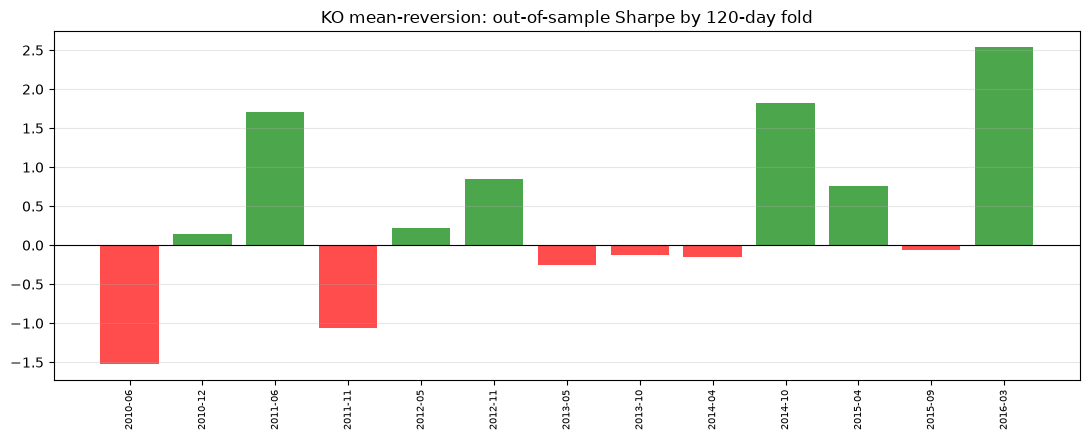

In [7]:
wf = walk_forward_validation(
    ko, mean_reversion_signal, bt, params={"window": 20, "entry_z": 1.0, "exit_z": 0.25},
    train_window=120, test_window=120,
)
win_rate = (wf["sharpe"] > 0).mean()
print(f"{len(wf)} folds, {win_rate:.1%} with positive Sharpe")

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["green" if s > 0 else "red" for s in wf["sharpe"]]
ax.bar(range(len(wf)), wf["sharpe"], color=colors, alpha=0.7)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(wf)))
ax.set_xticklabels([d.strftime("%Y-%m") for d in wf["fold_start"]], rotation=90, fontsize=7)
ax.set_title("KO mean-reversion: out-of-sample Sharpe by 120-day fold")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("mean_reversion_walkforward.png", dpi=110)
plt.show()


A bare majority of folds are profitable (~54%), meaningfully less
dominant than the aggregate Sharpe alone might suggest. This is a real
strategy with a genuine (CI-confirmed) edge on this specific asset, but
it isn't winning consistently fold-over-fold — the edge shows up more
reliably in the full-sample aggregate than in any given 6-month window.

## 7. Discussion: risks and when to use this strategy

**When it's likely to work:** stable, low-volatility instruments without
strong sustained directional trends — mature, lower-beta equities are a
plausible category, more so than young or momentum-driven assets.

**When it's likely to fail, badly:** anything with genuine sustained
trends. The BTC result here isn't a mild underperformance — it's close to
a worst-case outcome, because the strategy is structurally betting
against the exact behavior (strong, persistent trends) that defines that
asset over this sample.

**Risks and factors:**
- **This is the mirror-image risk to trend-following's whipsaw risk:**
  where trend-following can get chopped up by reversals inside a trend,
  mean-reversion can get run over by a trend that simply doesn't revert —
  and the BTC result shows how severe that can be when the mismatch is
  bad enough.
- **Volatility regime matters more than the strategy's own name
  suggests.** The regime-conditional split shows this strategy is really
  a bet on *low, contained* volatility more than it is a bet on
  "ranging" price action specifically — worth remembering when picking
  which assets to apply it to.
- **Tail/gap risk** — mean-reversion strategies are structurally exposed
  to the case where a large move is the start of new information being
  priced in, not noise; there's no explicit protection against that
  scenario built into this signal.
- **Capacity** — short-horizon mean-reversion is typically more
  capacity-constrained than trend-following, since it depends on
  short-lived, smaller-magnitude inefficiencies that are more easily
  arbitraged away by faster participants.
- **Reported edge is a full-sample aggregate, not a per-period
  guarantee** — the walk-forward win rate (~54%) is a meaningfully more
  modest picture than the single aggregate Sharpe on its own.
